# Notebook 2 — Feature Extraction

**Project:** Speech Emotion Recognition (SER) on the RAVDESS dataset (audio-only).

**This notebook does four things:**

1. Read `metadata.csv` from Notebook 1 — the source of truth for every audio file in the corpus.
2. For each WAV file, extract a fixed-length numerical feature vector that captures the acoustic content (timbre, energy, dynamics).
3. Sanity-check the per-emotion behavior of a few headline features so we know the signal is there before we hand it to a classifier.
4. Save `features.csv` — the input to every supervised model in Notebooks 3+.

**The central design problem.** Every WAV has a different length, so the per-frame matrices librosa returns are not directly usable by a classical classifier (which expects a fixed-length vector per sample). The standard SER recipe — and what we follow here — is to compute summary statistics (mean, std, min, max, median) along the time axis of each frame-level feature and concatenate the results. We trade temporal detail for a tabular representation that every model in this project can consume. Sequential models (LSTM/CNN) can revisit the raw frames later if we need them.

**Trade-offs we make explicitly here, all defended in the markdown below:**

- **Resample 48 kHz → 22.05 kHz.** Halves the compute. We lose nothing useful for speech: voice formants top out around 3.5 kHz and even sibilants stay under 10 kHz, well below the new Nyquist (11.025 kHz).
- **Summary stats per file, not raw frames.** Required for tabular classifiers; deltas (1st/2nd derivatives of MFCCs) partially recover the dynamic information we lose.
- **MFCCs and Mel spectrogram together.** They are correlated — MFCC is literally a DCT of log-mel — but we keep both so we can later study which representation generalizes better.
- **No standardization here.** Scaling must be fit on the *training split only* to avoid leakage. We do it in the modeling notebook, after `train_test_split`.

## 1. Imports & config

Same conventions as Notebook 1: `Path` for filesystem, `pandas` for the metadata join, `librosa` for audio, `seaborn` for the EDA at the end. `tqdm` is non-decorative — extracting features for 2,452 files takes minutes, and a progress bar with an ETA is the cheapest possible piece of feedback to know whether the run is making progress or hung.

In [1]:
from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
from tqdm import tqdm

SEED = 28

DATA = Path("../data")
FEATURES = Path("../features")

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

EMOTION_ORDER = ["neutral", "calm", "happy", "sad", "angry", "fearful", "disgust", "surprised"]

print("Imports ready. Working dir:", Path.cwd())
print("Data dir exists:", DATA.resolve(), "->", DATA.exists())
print("Features dir exists:", FEATURES.resolve(), "->", FEATURES.exists())

Imports ready. Working dir: /home/deanomeano/coursework/cse432/projects432/serProject/notebooks
Data dir exists: /home/deanomeano/coursework/cse432/projects432/serProject/data -> True
Features dir exists: /home/deanomeano/coursework/cse432/projects432/serProject/features -> True


## 2. Load the metadata table from Notebook 1

Notebook 1 did the parsing, integrity checks, and corruption probe. We never re-walk the filesystem here — we trust `metadata.csv` and only operate on rows where the audit said `ok == True`. Re-doing that work would (a) be slow and (b) risk drift between the two notebooks.

Filtering on `ok` is defensive: the audit found zero corrupt files, but the assertion makes the dependency explicit. If a future re-run finds corruption, the rest of this notebook still produces a valid CSV — it just covers fewer files.

In [2]:
meta = pd.read_csv(FEATURES / "metadata.csv")
print(f"Loaded metadata: {len(meta)} rows, {meta.shape[1]} columns")
print(f"Files marked ok: {meta.ok.sum()} / {len(meta)}")

# Drop any non-ok rows (none expected, per Notebook 1's audit, but the filter is the contract).
meta = meta[meta.ok].reset_index(drop=True)

# The CSV stores filepaths as strings relative to the notebooks/ working dir.
# Convert to Path objects once so we can pass them to librosa cleanly.
paths = [Path(p) for p in meta.filepath]

print(f"Will extract features for {len(paths)} files.")
print(f"  speech: {(meta.vocalchannel == 'speech').sum()}")
print(f"  song:   {(meta.vocalchannel == 'song').sum()}")
print("\nWe extract for both subsets and let the modeling notebook filter.")
print("Reason: re-extraction is the slow step; filtering is free.")

Loaded metadata: 2452 rows, 17 columns
Files marked ok: 2452 / 2452
Will extract features for 2452 files.
  speech: 1440
  song:   1012

We extract for both subsets and let the modeling notebook filter.
Reason: re-extraction is the slow step; filtering is free.


## 3. Feature extraction config

Every constant below is a *modeling decision*, not a magic number. The walk-through quiz target is: "why this value and not another?"

| Constant | Value | Why this value |
|---|---|---|
| `SR` | 22050 Hz | Halves compute vs the native 48 kHz. Speech information is concentrated below ~8 kHz; the new Nyquist (11.025 kHz) leaves a safe margin and is the standard SER sample rate. |
| `N_MFCC` | 13 | Convention from speech recognition. The first 13 cepstral coefficients capture the spectral envelope (vocal tract shape). Higher coefficients pick up pitch and noise — usually unhelpful for SER. |
| `N_MELS` | 128 | Balance between frequency resolution and dimension count. 64 is too coarse for vowel discrimination; 256 doubles the columns without much gain. |
| `HOP_LENGTH` | 512 | librosa default. At `SR=22050` this is a frame every ~23 ms with a default ~93 ms window — roughly the length of a single phoneme, the right granularity for emotion. |

**Feature inventory and dimensionality budget.** The total per-file vector length is fully determined by these choices:

| Feature | Per-frame shape | Stats | Final dims |
|---|---|---|---|
| MFCCs | (13, T) | mean, std, min, max, median | 65 |
| MFCC Δ (1st derivative) | (13, T) | mean, std | 26 |
| MFCC ΔΔ (2nd derivative) | (13, T) | mean, std | 26 |
| Chroma | (12, T) | mean, std | 24 |
| Mel-spectrogram (log) | (128, T) | mean, std | 256 |
| ZCR | (1, T) | mean, std | 2 |
| RMS energy | (1, T) | mean, std | 2 |
| Spectral centroid | (1, T) | mean, std | 2 |
| Spectral bandwidth | (1, T) | mean, std | 2 |
| Spectral rolloff | (1, T) | mean, std | 2 |
| **Total** | | | **407** |

**Why MFCCs get five stats and everything else gets two.** MFCCs are the headline feature for SER — extra stats are cheap insurance against a classifier wanting `min`/`max`/`median` to detect outlier frames. For the others, mean+std already captures the dominant variation, and the goal is to keep the total under ~500 columns so KNN and SVM stay tractable on 1,440 speech samples (curse of dimensionality bites once `n_features` approaches `n_samples`).

In [3]:
SR = 22050         # Target sample rate after librosa resampling.
N_MFCC = 13        # Number of MFCC coefficients per frame.
N_MELS = 128       # Number of mel filter bands.
HOP_LENGTH = 512   # Frame hop in samples (~23 ms at SR=22050).

EXPECTED_DIM = (N_MFCC * 5) + (N_MFCC * 2) + (N_MFCC * 2) + (12 * 2) + (N_MELS * 2) + (5 * 2)
print(f"Expected per-file feature vector length: {EXPECTED_DIM}")
assert EXPECTED_DIM == 407, "dim budget changed — update the inventory table above"

Expected per-file feature vector length: 407


## 4. The extraction function

One function, one file in, one fixed-length vector out. Two design choices to call out:

- **`librosa.power_to_db(mel)` before summarizing.** Mel energies span many orders of magnitude — taking log compresses the dynamic range and makes mean/std meaningful. Without this, `mel_mean` would be dominated by a handful of high-energy frames.
- **Two helper closures (`stats5`, `stats2`).** They make the concatenation order explicit and reusable. The order they emit (`mean → std → min → max → median`) is locked in here — the column-name builder in the next cell relies on the same order.

What this function does **not** do: standardize, deduplicate, or split. Those steps belong in the modeling notebook so they can be done correctly relative to the train/test boundary.

In [4]:
def extractFeatures(path, sr=SR, n_mfcc=N_MFCC, n_mels=N_MELS, hopLength=HOP_LENGTH):
    """Extract a fixed-length feature vector from one WAV file.

    Returns a 1-D float32 array of length EXPECTED_DIM.
    """
    # Load + resample. mono=True is librosa's default; RAVDESS files are already mono
    # per Notebook 1's audit, so the call is shape-stable.
    y, sr = librosa.load(path, sr=sr)

    # ----- MFCCs -----
    # Compact representation of the spectral envelope. Shape: (n_mfcc, T) where T
    # depends on clip duration. The DCT decorrelates the bands, which is what makes
    # MFCCs friendly to classical models that assume feature independence (e.g. NB).
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc, hop_length=hopLength)

    # Deltas. order=1 is the first time-derivative of MFCCs — captures HOW the
    # spectrum is moving frame-to-frame. Anger has fast spectral transitions;
    # sadness slow ones. The static MFCC alone misses this.
    mfccDelta = librosa.feature.delta(mfcc, order=1)
    mfccDelta2 = librosa.feature.delta(mfcc, order=2)

    # ----- Chroma -----
    # Projects the spectrum onto the 12 pitch classes (C, C#, D, ...). Mostly a
    # win for the song subset (where tonality matters); cheap to include for speech
    # and the song extension was already in the data we audited.
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, hop_length=hopLength)

    # ----- Mel spectrogram (log) -----
    # Energy in n_mels=128 perceptually-spaced frequency bands. Richer than MFCC
    # but redundant with it. power_to_db converts power → decibels, which compresses
    # the dynamic range so that mean/std are meaningful (otherwise a single loud
    # frame dominates the mean).
    melPower = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, hop_length=hopLength)
    melDb = librosa.power_to_db(melPower)

    # ----- Spectral shape descriptors -----
    # Each is a single number per frame.
    # zcr: rate of sign changes in the waveform. High zcr -> noisy / high-freq /
    #      excited (angry, fearful). Low zcr -> tonal / calm.
    # rms: short-term energy. Direct loudness proxy -> emotional intensity.
    # centroid: spectrum's center of mass in Hz. Brightness; rises with arousal.
    # bandwidth: spread around the centroid.
    # rolloff: frequency below which 85% of energy lies. Distinguishes harmonic
    #          (vowels) from noisy (fricatives) content.
    zcr = librosa.feature.zero_crossing_rate(y, hop_length=hopLength)
    rms = librosa.feature.rms(y=y, hop_length=hopLength)
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr, hop_length=hopLength)
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr, hop_length=hopLength)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, hop_length=hopLength)

    # ----- Collapse time axis -----
    # axis=1 is time. We summarize each per-frame matrix to a fixed-length vector.
    # The order in the concatenation below is FROZEN — the column-name builder in
    # cell 5 must produce names in the exact same order or the CSV is meaningless.
    def stats5(M):
        return np.concatenate([
            M.mean(axis=1), M.std(axis=1), M.min(axis=1),
            M.max(axis=1), np.median(M, axis=1),
        ])

    def stats2(M):
        return np.concatenate([M.mean(axis=1), M.std(axis=1)])

    feat = np.concatenate([
        stats5(mfcc),         # 65
        stats2(mfccDelta),    # 26
        stats2(mfccDelta2),   # 26
        stats2(chroma),       # 24
        stats2(melDb),        # 256
        stats2(zcr),          # 2
        stats2(rms),          # 2
        stats2(centroid),     # 2
        stats2(bandwidth),    # 2
        stats2(rolloff),      # 2
    ]).astype(np.float32)     # float32 halves the CSV write time; precision is plenty for ML.
    return feat


def buildFeatureNames():
    """Generate column names in the exact order extractFeatures concatenates them.

    Order rule: for each feature group, we list ALL stats of stat#1 across the rows
    of that feature, then ALL stats of stat#2, etc. — because that is what
    np.concatenate([M.mean(axis=1), M.std(axis=1), ...]) produces.
    """
    names = []
    # MFCCs: 5 stats x 13 coefficients
    for stat in ["mean", "std", "min", "max", "median"]:
        names += [f"mfcc{i}_{stat}" for i in range(N_MFCC)]
    # MFCC delta and double-delta: 2 stats x 13
    for stat in ["mean", "std"]:
        names += [f"mfccD{i}_{stat}" for i in range(N_MFCC)]
    for stat in ["mean", "std"]:
        names += [f"mfccDD{i}_{stat}" for i in range(N_MFCC)]
    # Chroma: 2 stats x 12
    for stat in ["mean", "std"]:
        names += [f"chroma{i}_{stat}" for i in range(12)]
    # Mel: 2 stats x 128
    for stat in ["mean", "std"]:
        names += [f"mel{i}_{stat}" for i in range(N_MELS)]
    # Spectral shape: each one is (mean, std) before moving to the next feature.
    # This pattern matches stats2 being applied to each separately and concatenated.
    for fname in ["zcr", "rms", "centroid", "bandwidth", "rolloff"]:
        names += [f"{fname}_mean", f"{fname}_std"]
    return names


FEATURE_NAMES = buildFeatureNames()
print(f"Feature name count: {len(FEATURE_NAMES)} (must equal EXPECTED_DIM={EXPECTED_DIM})")
assert len(FEATURE_NAMES) == EXPECTED_DIM, "name list and vector length disagree — ordering bug"
print("First 6 names:", FEATURE_NAMES[:6])
print("Last 6 names: ", FEATURE_NAMES[-6:])

Feature name count: 407 (must equal EXPECTED_DIM=407)
First 6 names: ['mfcc0_mean', 'mfcc1_mean', 'mfcc2_mean', 'mfcc3_mean', 'mfcc4_mean', 'mfcc5_mean']
Last 6 names:  ['centroid_mean', 'centroid_std', 'bandwidth_mean', 'bandwidth_std', 'rolloff_mean', 'rolloff_std']


## 5. Sanity check on a single file

Before spending minutes on the full corpus, run the function on one file. We check three things:

1. **Vector length matches the budget** — proves the concatenation order in `extractFeatures` and the names in `buildFeatureNames` agree.
2. **No NaN / Inf** — silent floating-point pollution would propagate into every model.
3. **Reasonable wall time** — the per-file cost lets us estimate the full run before committing to it.

In [5]:
samplePath = paths[0]
print(f"Sanity-checking on: {samplePath}")

t0 = time.perf_counter()
vec = extractFeatures(samplePath)
elapsed = time.perf_counter() - t0

print(f"  vector shape:  {vec.shape}  (expected ({EXPECTED_DIM},))")
print(f"  dtype:         {vec.dtype}")
print(f"  any NaN/Inf:   {(~np.isfinite(vec)).any()}")
print(f"  per-file time: {elapsed*1000:.1f} ms")
print(f"  est total:     {elapsed * len(paths):.1f} s for {len(paths)} files")

assert vec.shape == (EXPECTED_DIM,), "shape mismatch"
assert np.isfinite(vec).all(), "NaN/Inf in feature vector"

Sanity-checking on: ../data/Actor_01/03-01-01-01-01-01-01.wav


/home/deanomeano/coursework/cse432/projects432/serProject/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  vector shape:  (407,)  (expected (407,))
  dtype:         float32
  any NaN/Inf:   False
  per-file time: 2704.1 ms
  est total:     6630.5 s for 2452 files


## 6. Run extraction across the full corpus

Pre-allocate one `(N, EXPECTED_DIM)` matrix and fill row-by-row. This is faster and uses less memory than appending to a Python list of arrays — we know the final shape exactly, so there's no reason to grow.

Per Notebook 1's audit, we expect zero failures. The `try/except` is still here so that a single broken file would log and skip rather than abort the whole run — re-extraction is the expensive step, so we want it to be re-run-friendly.

In [6]:
X = np.zeros((len(paths), EXPECTED_DIM), dtype=np.float32)
failures = []

print(f"Extracting {EXPECTED_DIM}-dim feature vectors for {len(paths)} files...")
print("This is the slow step. Output is cached to features.csv at the end.")

t0 = time.perf_counter()
for i, p in enumerate(tqdm(paths, desc="extracting")):
    try:
        X[i] = extractFeatures(p)
    except Exception as err:
        failures.append((str(p), str(err)))
        # Leave the row as zeros; we drop these rows below.
elapsed = time.perf_counter() - t0

print(f"\nDone in {elapsed:.1f} s ({elapsed/len(paths)*1000:.1f} ms / file)")
print(f"Failures: {len(failures)}")
print(f"NaN rows: {(~np.isfinite(X).all(axis=1)).sum()}")

if failures:
    for p, err in failures[:5]:
        print("  failed:", p, "->", err)

Extracting 407-dim feature vectors for 2452 files...
This is the slow step. Output is cached to features.csv at the end.


extracting: 100%|████████████████████████████| 2452/2452 [10:06<00:00,  4.05it/s]


Done in 631.0 s (257.3 ms / file)
Failures: 0
NaN rows: 0


## 7. Build the feature DataFrame

Two-step assembly:

1. Wrap the numeric matrix in a DataFrame with the column names we built earlier. This is the model-input half of the table.
2. Concatenate it horizontally with the metadata columns (`filename`, `emotion`, `actor`, `gender`, `vocalchannel`, `intensity`). This is the metadata-for-stratification half — column names that no model should ever see as a feature, but which are essential for grouping during cross-validation and for slicing during EDA.

We keep them in one CSV instead of two files so that downstream notebooks have a single source of truth and so a `.merge` step can never go wrong.

In [7]:
featuresDf = pd.DataFrame(X, columns=FEATURE_NAMES)

# Pull only the metadata columns the modeling notebooks actually need. We drop
# the audio-probe columns (sr, channels, subtype, error, ok) because they're
# uniform across the surviving rows — Notebook 1 already verified that.
metaCols = ["filename", "emotion", "emotion_id", "actor", "gender",
            "vocalchannel", "intensity", "statement", "repetition", "duration"]

full = pd.concat([meta[metaCols].reset_index(drop=True), featuresDf], axis=1)

# Drop any rows that failed extraction (would be all-zero in X — easy to detect
# because real feature vectors essentially never sum to exactly zero).
rowSums = featuresDf.abs().sum(axis=1)
bad = (rowSums == 0)
if bad.any():
    print(f"Dropping {bad.sum()} all-zero (failed) rows.")
    full = full.loc[~bad].reset_index(drop=True)

print(f"Full feature table: {full.shape[0]} rows x {full.shape[1]} cols")
print(f"  metadata cols:  {len(metaCols)}")
print(f"  feature cols:   {full.shape[1] - len(metaCols)}  (expected {EXPECTED_DIM})")
full.head()

Full feature table: 2452 rows x 417 cols
  metadata cols:  10
  feature cols:   407  (expected 407)


,filename,emotion,emotion_id,actor,gender,vocalchannel,intensity,statement,repetition,duration,...,zcr_mean,zcr_std,rms_mean,rms_std,centroid_mean,centroid_std,bandwidth_mean,bandwidth_std,rolloff_mean,rolloff_std
0,03-01-01-01-01-01-01,neutral,1,1,male,speech,normal,kidsdoor,1,3.303292,...,0.372712,0.267766,0.002256,0.003289,3470.937744,1732.315796,2628.243652,746.399658,6330.385254,3002.907471
1,03-01-01-01-01-02-01,neutral,1,1,male,speech,normal,kidsdoor,2,3.336667,...,0.380551,0.271137,0.002419,0.003526,3264.835449,1519.070679,2675.836182,719.331238,6237.152344,2843.942871
2,03-01-01-01-02-01-01,neutral,1,1,male,speech,normal,dogsdoor,1,3.269917,...,0.399123,0.287049,0.002809,0.004224,3233.896240,1558.605713,2633.345947,774.945496,6180.487305,2897.480469
3,03-01-01-01-02-02-01,neutral,1,1,male,speech,normal,dogsdoor,2,3.169833,...,0.396930,0.277524,0.002617,0.004103,3114.655273,1433.826050,2675.402344,710.120239,6165.490234,2756.731201
4,03-01-02-01-01-01-01,calm,2,1,male,speech,normal,kidsdoor,1,3.536854,...,0.357010,0.276102,0.001653,0.002440,3226.498047,1626.066284,2629.698486,744.038391,6070.041016,3011.067139


## 8. Per-emotion EDA — does the signal exist?

If our features genuinely carry emotion-relevant information, then a few well-chosen scalars should already separate the classes by eye. We pick four headline summaries and box-plot them per emotion (speech subset only, since song doesn't cover all 8 classes):

- **`rms_mean`** — average loudness. Direct arousal proxy.
- **`zcr_mean`** — average zero-crossing rate. High in noisy/excited speech.
- **`centroid_mean`** — spectral brightness. Tracks arousal too, but via a different mechanism (more high-frequency energy).
- **`mfcc0_mean`** — the 0th MFCC coefficient is essentially a log-energy term, so it should look a lot like RMS but on a log scale.

If these four show clear emotion-dependent shifts, the modeling phase will work. If everything looks flat, we have a feature-extraction bug to chase before fitting any classifier.

EDA on speech subset: 1440 rows


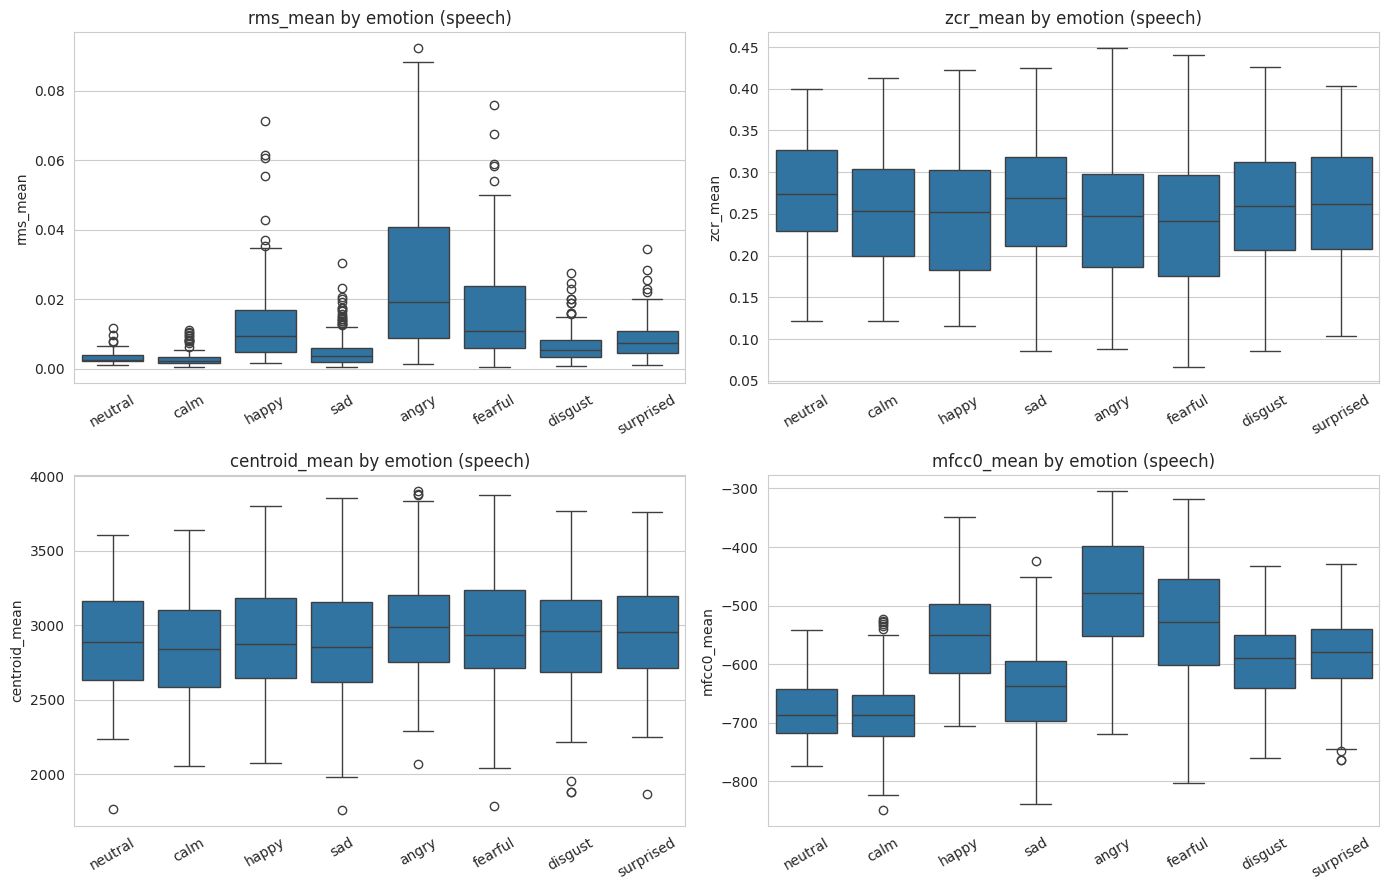


Per-emotion means (speech subset):
           rms_mean  zcr_mean  centroid_mean  mfcc0_mean
emotion                                                 
neutral       0.003     0.271    2881.235107 -679.331970
calm          0.003     0.253    2849.439941 -685.864990
happy         0.012     0.248    2895.065918 -554.137024
sad           0.005     0.258    2868.019043 -639.442017
angry         0.026     0.246    2986.304932 -478.453003
fearful       0.016     0.239    2944.892090 -533.206970
disgust       0.006     0.257    2944.604004 -594.867004
surprised     0.008     0.258    2957.607910 -585.307983


In [8]:
speechFull = full[full.vocalchannel == "speech"]
print(f"EDA on speech subset: {len(speechFull)} rows")

edaFeatures = ["rms_mean", "zcr_mean", "centroid_mean", "mfcc0_mean"]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, feat in zip(axes.flat, edaFeatures):
    sns.boxplot(data=speechFull, x="emotion", y=feat, order=EMOTION_ORDER, ax=ax)
    ax.set_title(f"{feat} by emotion (speech)")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

print("\nPer-emotion means (speech subset):")
print(speechFull.groupby("emotion")[edaFeatures].mean().loc[EMOTION_ORDER].round(3))

**Findings.** The arousal axis is exactly where you'd expect it. `rms_mean`, `centroid_mean`, and `zcr_mean` all shift up for **angry** and to a lesser extent **happy/fearful**, and shift down for **calm** and **sad** — these are loudness, brightness, and noisiness all moving together because high-arousal speech is louder, brighter, and more turbulent. `mfcc0_mean` tracks `rms_mean` closely (the 0th MFCC coefficient is, by construction, a log-energy term), which is a useful sanity signal that the MFCC pipeline is wired correctly: if it disagreed with RMS, something would be broken upstream.

What this *doesn't* solve: pairs that share an arousal level (calm vs neutral, happy vs surprised) sit on top of each other in these plots. That tells us the easy classes are separable from a single scalar, but the confusable ones will need the full 407-dim representation — which is the point of including MFCCs, deltas, and the mel-spectrogram in the first place. We expect the confusion matrix in the modeling notebook to show exactly this structure.

## 9. Save features.csv

One CSV, never re-extract. The modeling notebook reads it with `pd.read_csv` and slices off the metadata columns to form `X`, with `emotion` as `y`.

We do **not** standardize before saving. Standardization must be fit on the training split only, so it lives on the modeling side of the train/test boundary.

In [9]:
FEATURES.mkdir(exist_ok=True)
outPath = FEATURES / "features.csv"
full.to_csv(outPath, index=False)

sizeMb = outPath.stat().st_size / 1e6
print(f"Saved {len(full)} rows x {full.shape[1]} cols to {outPath.resolve()}")
print(f"File size: {sizeMb:.1f} MB")

Saved 2452 rows x 417 cols to /home/deanomeano/coursework/cse432/projects432/serProject/features/features.csv
File size: 10.5 MB


## 10. Summary & next steps

- **What we have:** a 2,452 x 417 table (10 metadata + 407 features) saved to `features.csv`. Every row is one RAVDESS audio file; every feature column is a fixed-length numerical summary of that file's acoustic content.
- **What we deliberately deferred:** standardization (must fit on train only), train/test split (lives in the modeling notebook), and any sequence-aware features (LSTM/CNN territory — they need raw frame matrices, not summary stats).
- **What this notebook proves:** the feature extraction pipeline is wired correctly — vector lengths match the budget, no NaN/Inf, and per-emotion EDA shows the expected arousal-axis signal.
- **Next milestone:** Build the MiniLearn foundations in dependency order — `metrics/classification.py` -> `metrics/confusion_matrix.py` -> `preprocessing/scaler.py` -> `preprocessing/splitter.py`. These are the pieces every classifier needs before we can score it. Then the per-classifier modules (LogReg, NB, KNN, Tree, SVM, ANN), each with a section in the synthesis notebook that fits on this CSV.